In [2]:
import pandas as pd

In [3]:
from sklearn.datasets import fetch_california_housing

In [4]:
df = fetch_california_housing(as_frame=True).frame

In [8]:
list(df.columns)

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'MedHouseVal']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [17]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


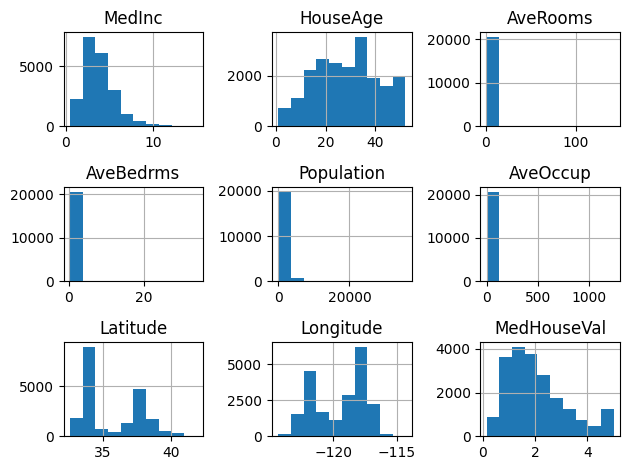

In [11]:
import matplotlib.pyplot as plt

df.hist()
#plt.title('House')
plt.tight_layout()
plt.show()

In [13]:
import yfinance as yf

apple_df = yf.download('AAPL')

[*********************100%***********************]  1 of 1 completed


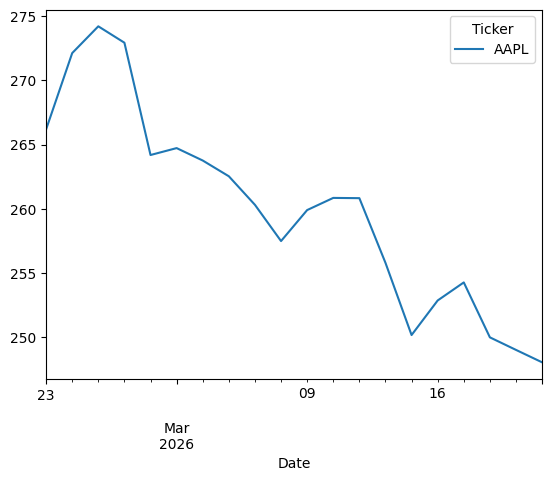

In [14]:
apple_df.Close.plot()
plt.show()

In [15]:
df.iloc[20630:-1, 6:8]

,Latitude,Longitude
20630,39.29,-121.32
20631,39.33,-121.40
20632,39.26,-121.45
20633,39.19,-121.53
20634,39.27,-121.56
20635,39.48,-121.09
20636,39.49,-121.21
20637,39.43,-121.22
20638,39.43,-121.32


In [56]:
new_df = pd.DataFrame({
    'name': ['Mike', 'Alice', 'Bob'],
    'age': [ 30, 45, 80],
    'job': ['Programmer', 'Designer', 'Accountant']
})


In [58]:
new_df = new_df.set_index('name')

In [62]:
new_df.loc['Mike'].job

'Programmer'

In [23]:
def ageAdjustment(x):
     if (x // 2 > 22):
            return x // 2
     else:
            return x 

In [67]:
new_df.age = new_df.age.apply(ageAdjustment)

In [36]:
def jobAdjustment(x):
    if x.endswith('r'):
        return 'Without Job'
    else:
        return x

In [69]:
new_df.job = new_df.job.apply(jobAdjustment)

In [65]:
new_df.loc['John'] = [90, 'Teacher']

In [90]:
new_df

,age,job,summary
name,,,
Mike,30,Without Job,"Age: 30, Job: Without Job"
Alice,45,Without Job,"Age: 45, Job: Without Job"
Bob,80,Accountant,"Age: 80, Job: Accountant"
John,90,Without Job,"Age: 90, Job: Without Job"


In [97]:
new_df.at['Alice', 'age'] = None

In [89]:
new_df['summary'] = new_df.apply(lambda row: f'Age: {row["age"]}, Job: {row["job"]}', axis=1)

In [91]:
new_df.drop(['age','job'],axis=1)

,summary
name,
Mike,"Age: 30, Job: Without Job"
Alice,"Age: 45, Job: Without Job"
Bob,"Age: 80, Job: Accountant"
John,"Age: 90, Job: Without Job"


In [98]:
new_df

,age,job,summary
name,,,
Mike,30.0,Without Job,"Age: 30, Job: Without Job"
Alice,NaN,Without Job,"Age: 45, Job: Without Job"
Bob,80.0,Accountant,"Age: 80, Job: Accountant"
John,90.0,Without Job,"Age: 90, Job: Without Job"


In [106]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, Mike to John
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      3 non-null      float64
 1   job      3 non-null      object 
 2   summary  4 non-null      object 
dtypes: float64(1), object(2)
memory usage: 300.0+ bytes


In [100]:
new_df.age.fillna(new_df.age.mean())

name
Mike     30.000000
Alice    66.666667
Bob      80.000000
John     90.000000
Name: age, dtype: float64

In [105]:
new_df.at['Bob', 'job'] = None

In [112]:
new_df[~new_df.age.notnull()]

,age,job,summary
name,,,
Alice,NaN,Without Job,"Age: 45, Job: Without Job"


In [109]:
new_df.notna()

,age,job,summary
name,,,
Mike,True,True,True
Alice,False,True,True
Bob,True,False,True
John,True,True,True


In [116]:
for i, row in new_df.iterrows():
    print (row['age'])

30.0
nan
80.0
90.0


In [118]:
for i, col in new_df.items():
    print (col['Alice'])

nan
Without Job
Age: 45, Job: Without Job


In [119]:
new_df.age > 50

name
Mike     False
Alice    False
Bob       True
John      True
Name: age, dtype: bool

In [125]:
new_df[[True, True, False, True]]

,name,age,job,summary
0,Mike,30.0,Without Job,"Age: 30, Job: Without Job"
1,Alice,NaN,Without Job,"Age: 45, Job: Without Job"
3,John,90.0,Without Job,"Age: 90, Job: Without Job"


In [124]:
new_df = new_df.reset_index()

In [131]:
new_df[(new_df.name.str.contains('i')) & ~(new_df.age < 50)]

,name,age,job,summary
1,Alice,NaN,Without Job,"Age: 45, Job: Without Job"


In [181]:
import datetime as dt

In [182]:
new_df['birthday'] = new_df['age'].apply(lambda x: dt.datetime.now() - dt.timedelta(days=365*x))

In [197]:
new_df

,name,age,job,birthday
0,Mike,30.000000,Without Job,1996-03-27 15:27:27.347772
1,Alice,66.666667,Without Job,1959-08-06 07:27:27.347794
2,Bob,80.000000,None,1946-04-09 15:27:27.347797
3,John,90.000000,Without Job,1936-04-11 15:27:27.347799
4,Jane,35.000000,Programmer,NaT


In [191]:
new_df=new_df.drop('summary',axis=1)

In [155]:
new_df.age = new_df['age'].fillna(new_df.age.mean())

In [187]:
new_df[new_df.age.isin([30,12]) ]

,name,age,job,summary,birthday
0,Mike,30.0,Without Job,"Age: 30, Job: Without Job",1996-03-27 15:27:27.347772


In [199]:
new_df.groupby('job').agg({
   'age': ['mean','max','min'],
    'name': 'max'
}  )

age              name
                  mean   max   min   max
job                                     
Programmer   35.000000  35.0  35.0  Jane
Without Job  62.222222  90.0  30.0  Mike